**Implementación de modelos supervisados (clasificación y regresión) con Scikit-learn.**

### Importe de librerías necesarias


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocesamiento.data_preprocessing import corregir_valores_negativos
from preprocesamiento.data_preprocessing import detectar_inconsistencias
from preprocesamiento.data_preprocessing import separar_objetivo_features
from preprocesamiento.data_preprocessing import eliminar_nulos_objetivo
from preprocesamiento.pipelines import aplicar_pipeline_limpieza_train_test
from preprocesamiento.pipelines import build_cleaning_pipeline_reg
from preprocesamiento.pipelines import build_decision_tree_regressor_pipeline
from preprocesamiento.pipelines import build_linear_regression_pipeline
from preprocesamiento.pipelines import build_preprocessor
from model_evaluation import evaluar_regresor
from model_training import entrenar_modelo

### Carga de Datos

In [3]:
url = "https://raw.githubusercontent.com/ramirezluna-david/proyecto_modelado_grp2/rama_david/data/dataset_clientes.csv"
data = pd.read_csv(url)

### Preprocesamiento de datos

#### Detección de inconsistencias

In [4]:
# Detección de inconsistencias: negativos o ceros en columnas que deberían ser positivas.
conteo_negativos, conteo_ceros = detectar_inconsistencias(data)

Negativos detectados: {'ingreso_mensual': 11, 'gasto_mensual': 68, 'deuda_total': 143}
Ceros detectados: ninguno


In [5]:
# Tratamiento: corrige valores negativos convirtiéndolos a valor absoluto.
data = corregir_valores_negativos(data)

Valores negativos corregidos a valores absolutos en las columnas relevantes.


# 1. Modelamiento para variable objetivo "gasto_mensual"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [6]:
data_filtrada = eliminar_nulos_objetivo(data, target="gasto_mensual")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="gasto_mensual",
 )

In [7]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [8]:
numerical_features = ["deuda_total", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [9]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "gasto_mensual"

### Pipeline para Regresión Lineal

In [10]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [11]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.006024,-0.564952,-0.725085,-1.252092,-0.146884,0.002178,-0.664779,0.710448,-0.942637,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0
1,1.056188,0.677679,-1.002381,-1.140394,-1.167320,0.002178,-0.037163,1.421698,0.794582,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.344691,-1.571082,0.195988,-0.190961,0.756931,-1.281159,-0.721835,1.421698,-1.087405,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
3,-0.096538,-0.819964,0.317650,-1.531336,1.398348,1.102181,0.771131,0.710448,1.663191,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0
4,-0.407011,-2.179634,-0.383648,0.088283,-0.263505,-0.914491,-0.712326,1.421698,-0.942637,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [12]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [13]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((13300, 10), (5700, 10))

### Entrenamiento


In [14]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [15]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : 0.001
MAE   : 118,595


In [16]:
# Variables que fueron eliminadas por presentar colinealidad
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [17]:
# Variables con las cuales fue entrenado el modelo
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=9):
- abandono_0
- tipo_plan
- dia_semana_registro_Viernes
- region_Norte
- canal_registro_App
- dia_semana_registro_Jueves
- uso_app
- estado_civil_Soltero
- region_Sur


## Modelo DecisionTreeRegressor para "gasto_mensual"

### Pipeline para DecisionTreeRegressor

In [18]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [19]:
# Divide en train/test antes de ajustar el pipeline
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.3, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.006024,-0.564952,-0.725085,-1.252092,-0.146884,0.002178,-0.664779,0.710448,-0.942637,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0
1,1.056188,0.677679,-1.002381,-1.140394,-1.167320,0.002178,-0.037163,1.421698,0.794582,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.344691,-1.571082,0.195988,-0.190961,0.756931,-1.281159,-0.721835,1.421698,-1.087405,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
3,-0.096538,-0.819964,0.317650,-1.531336,1.398348,1.102181,0.771131,0.710448,1.663191,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0
4,-0.407011,-2.179634,-0.383648,0.088283,-0.263505,-0.914491,-0.712326,1.421698,-0.942637,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [20]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [21]:
# El split ya se hizo antes del fit del pipeline
X_train.shape, X_test.shape

((13300, 10), (5700, 10))

### Entrenamiento

In [22]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [23]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : -0.017
MAE   : 119,653


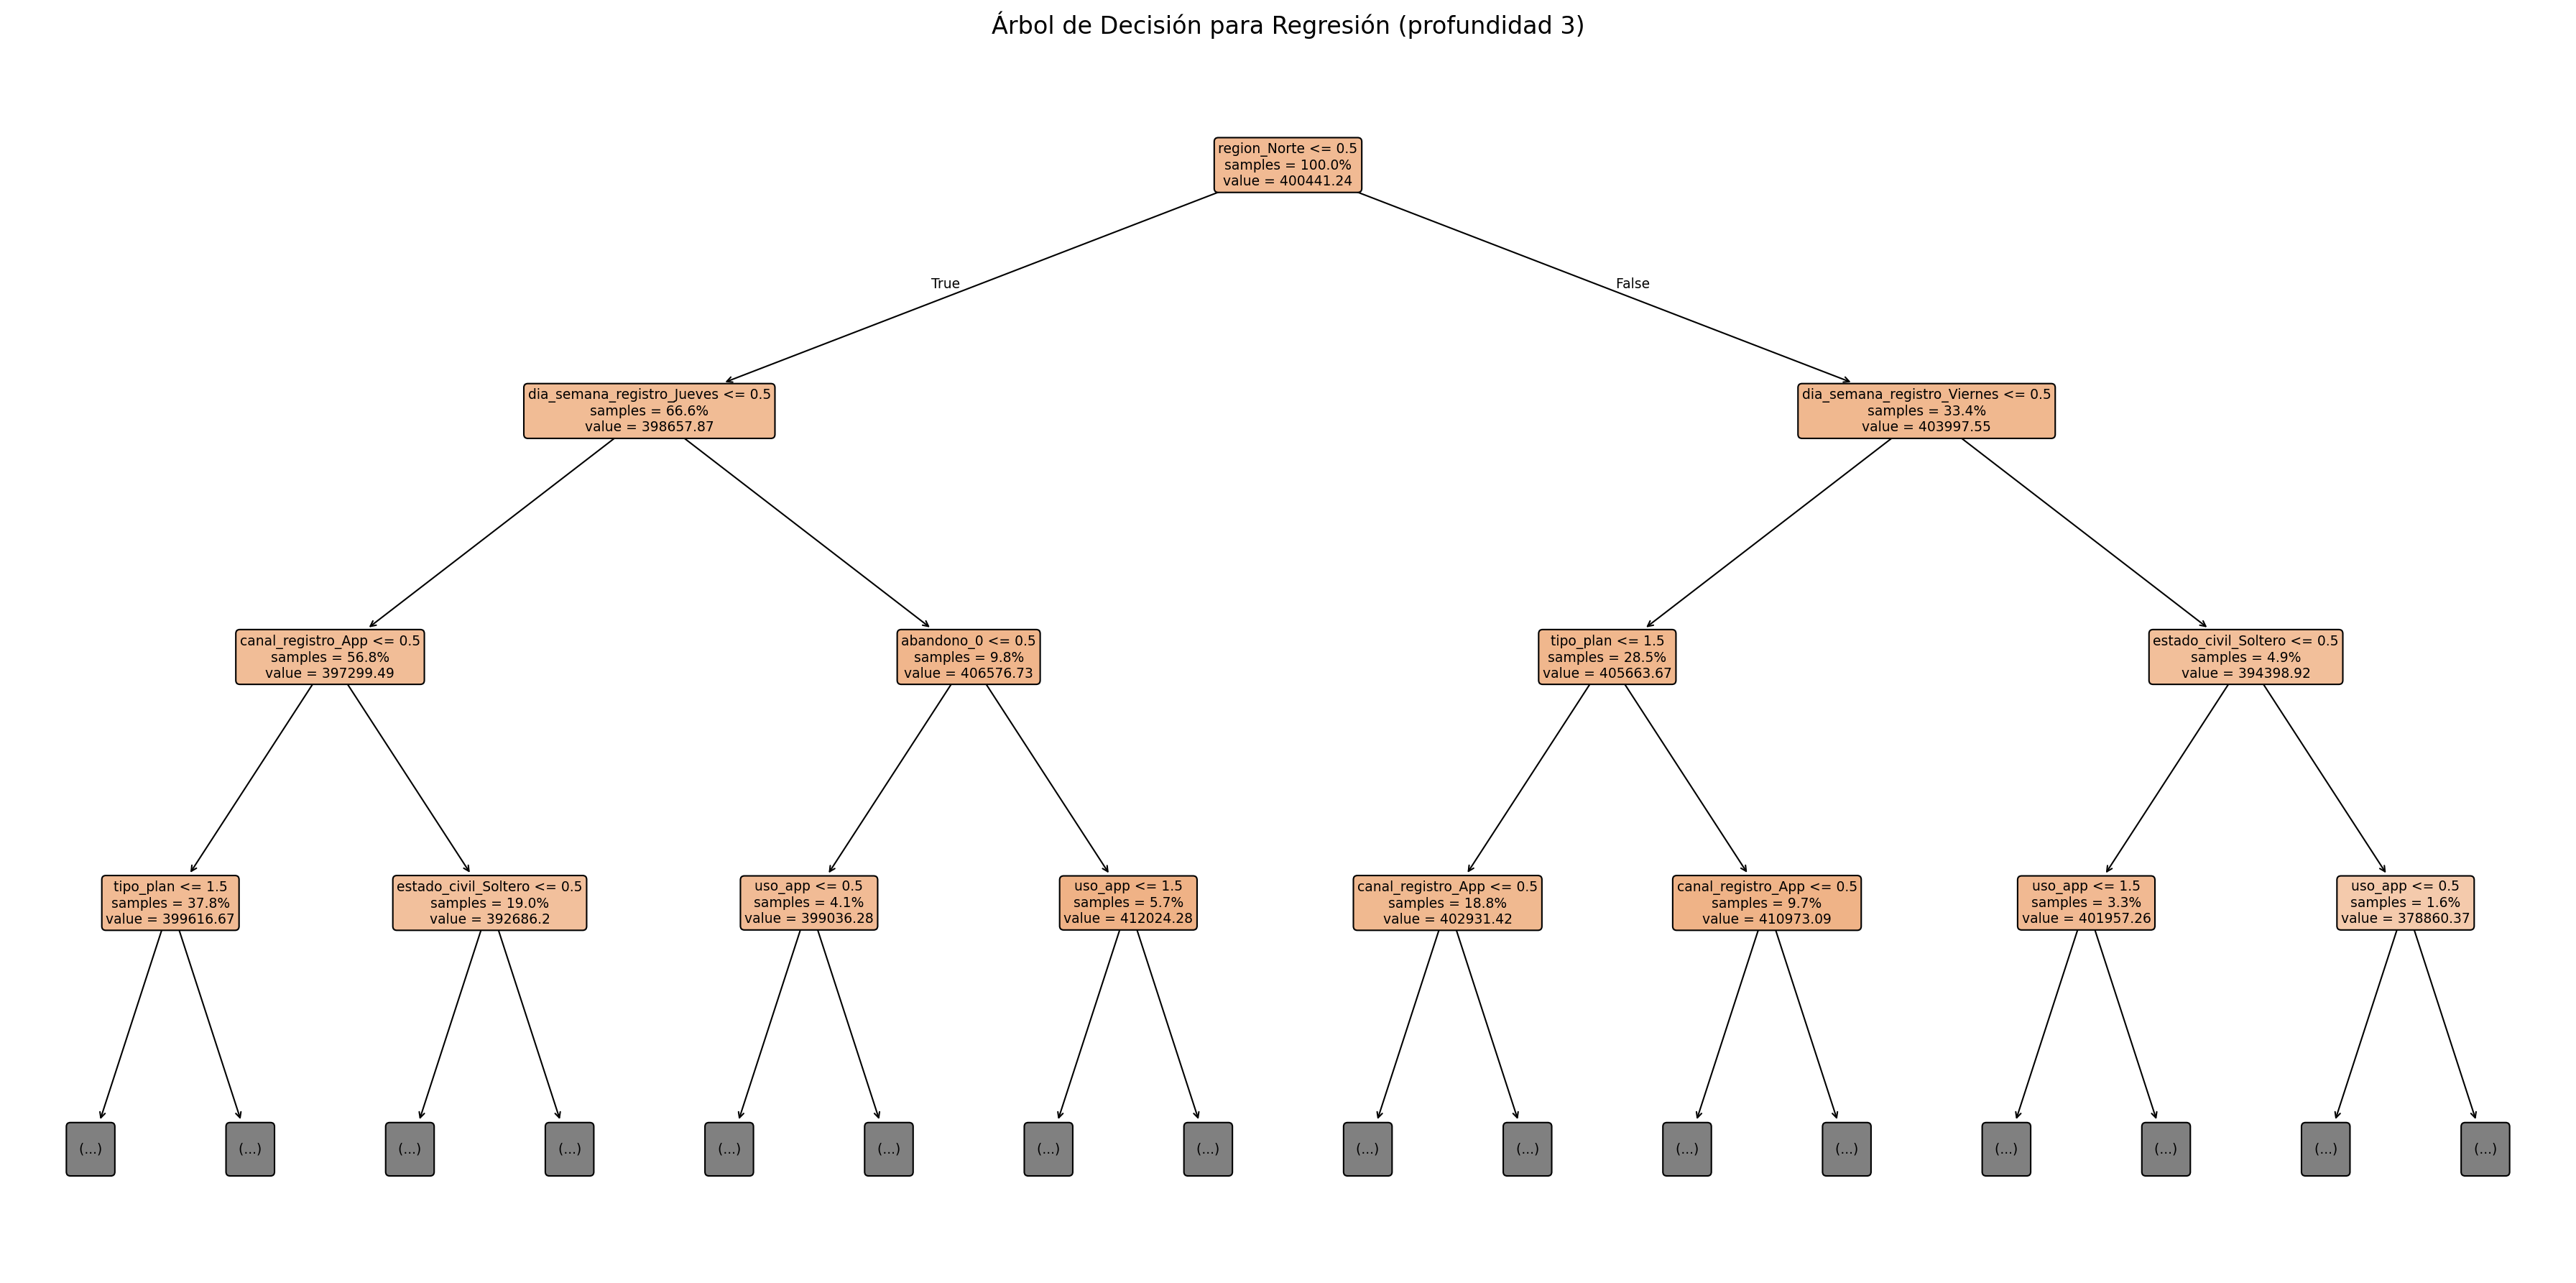

In [24]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

In [25]:
base_dir = project_root if "project_root" in globals() else Path.cwd().resolve()

models_dir = base_dir / "models"
processed_dir = base_dir / "data" / "processed"
models_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

# guarda los modelos/pipelines entrenados
joblib.dump(pipeline_modelo_lr, models_dir / "pipeline_modelo_lr.joblib")
joblib.dump(pipeline_modelo_dtr, models_dir / "pipeline_modelo_dtr.joblib")

# guarda los sets de prueba para asegurar consistencia
joblib.dump(X_test, processed_dir / "X_test.joblib")
joblib.dump(y_test, processed_dir / "y_test.joblib")

print("Modelos y datos de prueba guardados")

Modelos y datos de prueba guardados


# 2. Modelamiento para variable objetivo "abandono"